# Fase 1: Exploratory Data Analysis & Baseline (Kaplan-Meier)

**ADVERTENCIA**: Este análisis se realiza **ÚNICAMENTE** sobre el conjunto de entrenamiento (`data/interim/data_train.csv`) para evitar data leakage.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
#import seaborn as sns
import os

# Estética
#sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# 1. Cargar Datos de Train
train_path = '../data/interim/data_train.csv'
df_train = pd.read_csv(train_path)

print(f"Dimensiones Train: {df_train.shape}")
display(df_train.head())

Dimensiones Train: (65451, 17)


,patientunitstayid,gender,age,ethnicity,first_careunit,admission_location,insurance,hour,eyes,height,motor,verbal,weight,uniquepid,patienthealthsystemstayid,actualhospitalmortality,actualiculos
0,35069297,M,53,WHITE,Cardiac Vascular Intensive Care Unit (CVICU),PROCEDURE SITE,Private,14,2.0,175.0,1.0,1.0,63.5,19758855,27484643,0,0.997905
1,32958293,M,48,BLACK/AFRICAN AMERICAN,Coronary Care Unit (CCU),PHYSICIAN REFERRAL,Medicare,23,4.0,185.0,6.0,5.0,75.0,13480812,23546785,0,0.819942
2,30979691,F,36,PORTUGUESE,Neuro Intermediate,TRANSFER FROM HOSPITAL,Private,20,4.0,NaN,6.0,5.0,77.0,14043984,24561034,0,4.784965
3,33467361,M,81,ASIAN - CHINESE,Medical/Surgical Intensive Care Unit (MICU/SICU),PHYSICIAN REFERRAL,Medicaid,8,3.0,160.0,5.5,3.0,65.9,18801958,26420020,1,1.405590
4,36471967,F,76,BLACK/AFRICAN AMERICAN,Medical/Surgical Intensive Care Unit (MICU/SICU),EMERGENCY ROOM,Medicare,15,4.0,165.0,6.0,5.0,70.7,14436564,25346439,0,0.978900


## Verificación de Data Leakage

Comprobamos que no haya intersección de pacientes (`uniquepid` o `patientunitstayid`) entre los conjuntos de Train, Val y Test.

In [4]:
# Cargar rutas de las otras particiones
val_path = "../data/interim/data_val.csv"
test_path = "../data/interim/data_test.csv"

df_val = pd.read_csv(val_path)
df_test = pd.read_csv(test_path)

train_pids = set(df_train["patientunitstayid"])
val_pids = set(df_val["patientunitstayid"])
test_pids = set(df_test["patientunitstayid"])

train_val_overlap = len(train_pids.intersection(val_pids))
train_test_overlap = len(train_pids.intersection(test_pids))
val_test_overlap = len(val_pids.intersection(test_pids))

print(f"Overlap Train - Val: {train_val_overlap}")
print(f"Overlap Train - Test: {train_test_overlap}")
print(f"Overlap Val - Test: {val_test_overlap}")

assert train_val_overlap == 0, "WARNING: Patient overlap between Train and Validation sets!"
assert train_test_overlap == 0, "WARNING: Patient overlap between Train and Test sets!"
assert val_test_overlap == 0, "WARNING: Patient overlap between Validation and Test sets!"

print("\nÉXITO: No hay fuga de datos de pacientes entre los conjuntos.")


Overlap Train - Val: 0
Overlap Train - Test: 0
Overlap Val - Test: 0

ÉXITO: No hay fuga de datos de pacientes entre los conjuntos.


## Visualización Baseline: Curva de Supervivencia Global

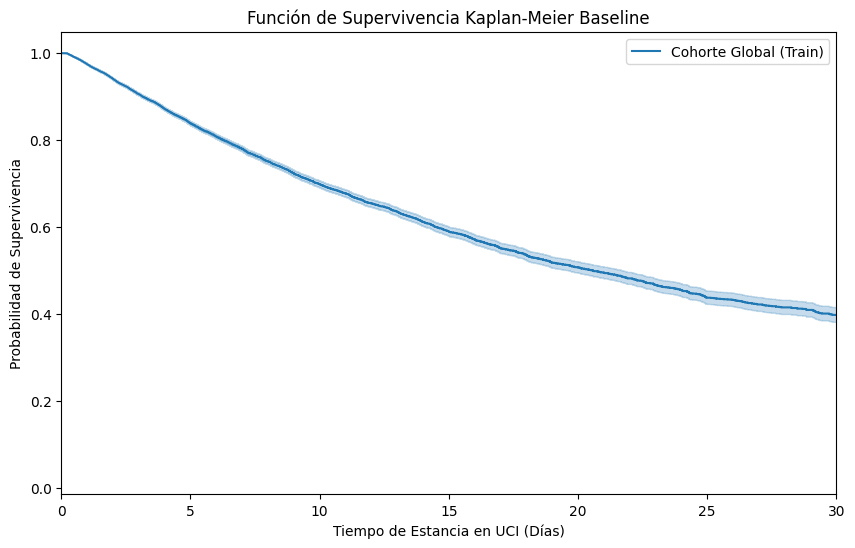

In [5]:
kmf = KaplanMeierFitter()

T = df_train['actualiculos'] # Tiempo en UCI
E = df_train['actualhospitalmortality'] # Evento (Mortalidad)

kmf.fit(durations=T, event_observed=E, label='Cohorte Global (Train)')

kmf.plot_survival_function(ci_show=True)
plt.title('Función de Supervivencia Kaplan-Meier Baseline')
plt.xlabel('Tiempo de Estancia en UCI (Días)')
plt.ylabel('Probabilidad de Supervivencia')
plt.xlim(0, 30) # Limitar la vista a 30 días para mayor claridad
plt.show()

In [8]:
import pandas as pd

# Columnas de supervivencia
time_col = "actualiculos"              # tiempo en UCI, en días
event_col = "actualhospitalmortality"  # 1 = muerte, 0 = censura

# Landmarks en horas y ventana de predicción
landmarks_h = [0, 24, 48,72, 96, 120, 144, 168, 192, 216, 240]  # cada 24 horas desde las 72h hasta las 240h
window_h = 10 * 24

rows = []

for landmark_h in landmarks_h:
    landmark_d = landmark_h / 24
    window_d = window_h / 24

    # Pacientes que siguen bajo observación justo al llegar al landmark
    at_risk = df_train[time_col] > landmark_d

    # Eventos/censuras que ocurren en los 10 días posteriores al landmark
    in_window = (
        (df_train[time_col] > landmark_d) &
        (df_train[time_col] <= landmark_d + window_d)
    )

    n_at_risk = at_risk.sum()
    n_events = (in_window & (df_train[event_col] == 1)).sum()
    n_censored = (in_window & (df_train[event_col] == 0)).sum()

    rows.append({
        "Landmark": f"{landmark_h}h",
        "Pacientes en riesgo": n_at_risk,
        "Eventos próximos 10 días": n_events,
        "Censurados próximos 10 días": n_censored,
        "% eventos próximos 10 días": n_events / n_at_risk * 100
    })

landmark_table = pd.DataFrame(rows)

landmark_table

,Landmark,Pacientes en riesgo,Eventos próximos 10 días,Censurados próximos 10 días,% eventos próximos 10 días
0,0h,65451,6607,54104,10.094575
1,24h,52357,5209,42996,9.949004
2,48h,32417,3897,24887,12.021470
3,72h,21745,2972,15581,13.667510
4,96h,15683,2392,10523,15.252184
5,120h,11983,1959,7602,16.348160
6,144h,9569,1634,5797,17.075975
7,168h,7815,1397,4519,17.875880
8,192h,6496,1179,3613,18.149631
9,216h,5507,1009,2988,18.322135


In [10]:
landmark_table[[
    "Landmark",
    "Pacientes en riesgo",
    "Eventos próximos 10 días",
    "Censurados próximos 10 días"
]]

,Landmark,Pacientes en riesgo,Eventos próximos 10 días,Censurados próximos 10 días
0,0h,65451,6607,54104
1,24h,52357,5209,42996
2,48h,32417,3897,24887
3,72h,21745,2972,15581
4,96h,15683,2392,10523
5,120h,11983,1959,7602
6,144h,9569,1634,5797
7,168h,7815,1397,4519
8,192h,6496,1179,3613
9,216h,5507,1009,2988


## Supervivencia Estratificada por Género

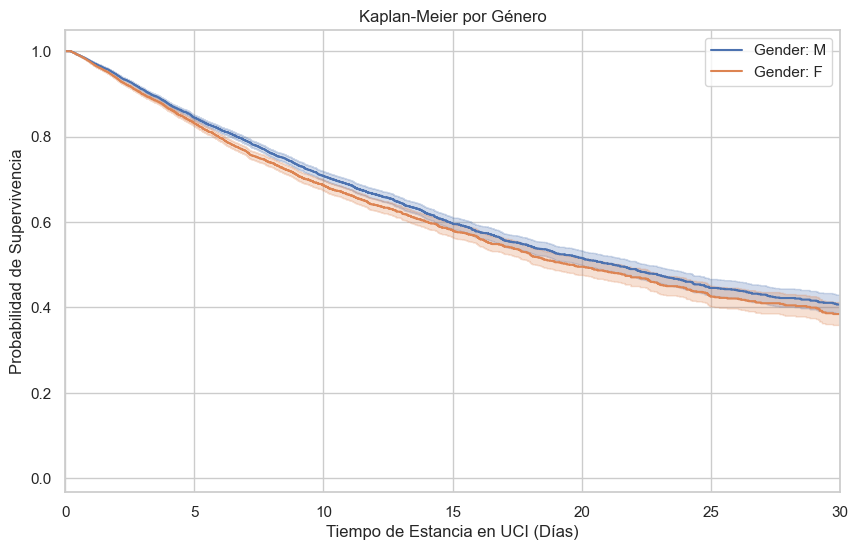

In [21]:
ax = plt.subplot(111)

for gender in df_train['gender'].dropna().unique():
    mask = df_train['gender'] == gender
    kmf.fit(T[mask], event_observed=E[mask], label=f'Gender: {gender}')
    kmf.plot_survival_function(ax=ax, ci_show=True)

plt.title('Kaplan-Meier por Género')
plt.xlabel('Tiempo de Estancia en UCI (Días)')
plt.ylabel('Probabilidad de Supervivencia')
plt.xlim(0, 30)
plt.show()

## Análisis de Valores Nulos

C:\Users\Javi\AppData\Local\Temp\ipykernel_28788\3340531695.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_pct.values, y=null_pct.index, palette='viridis')


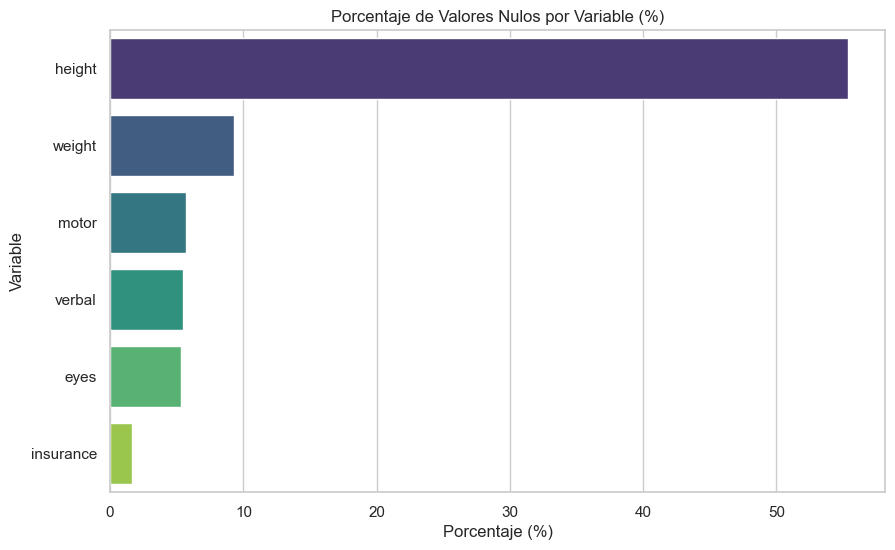

Variables con nulos y su porcentaje:


height       55.394112
weight        9.274113
motor         5.706559
verbal        5.449879
eyes          5.292509
insurance     1.637866
dtype: float64

In [22]:
null_pct = df_train.isnull().mean() * 100
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=null_pct.values, y=null_pct.index, palette='viridis')
plt.title('Porcentaje de Valores Nulos por Variable (%)')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Variable')
plt.show()

print('Variables con nulos y su porcentaje:')
display(null_pct)

## Distribución de Variables Categóricas

C:\Users\Javi\AppData\Local\Temp\ipykernel_28788\3373531559.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=plot_data, y=col, order=order, palette='Set2')


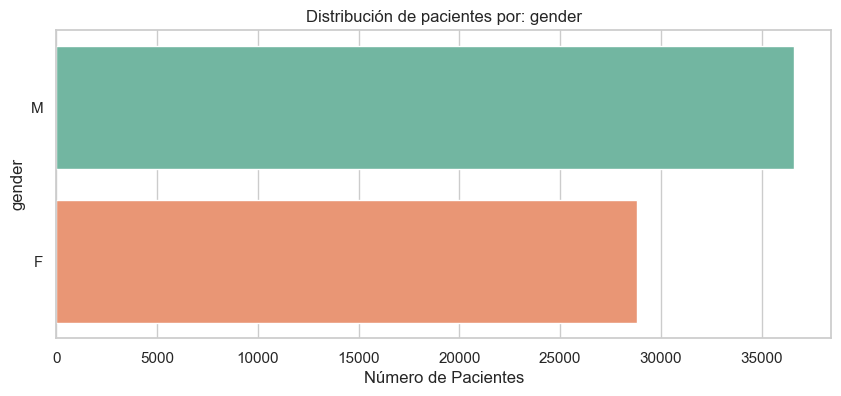


Mostrando top 20 categorías de ethnicity (total: 33)


C:\Users\Javi\AppData\Local\Temp\ipykernel_28788\3373531559.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=plot_data, y=col, order=order, palette='Set2')


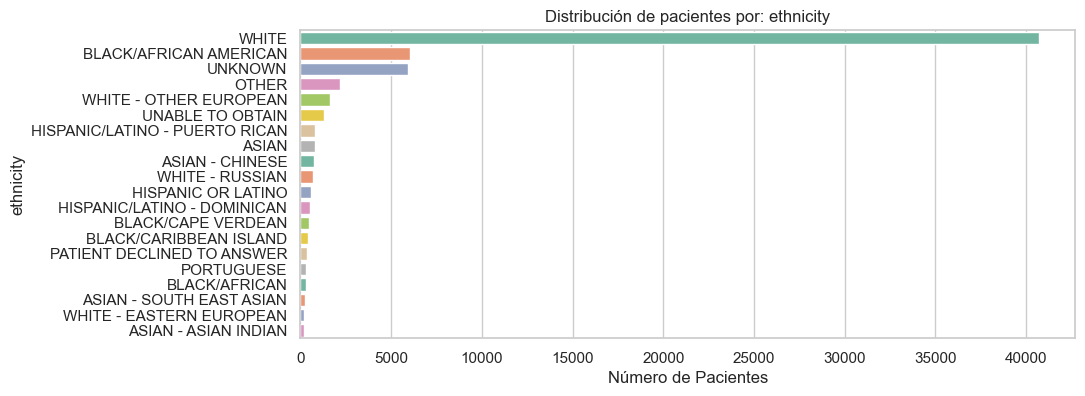

C:\Users\Javi\AppData\Local\Temp\ipykernel_28788\3373531559.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=plot_data, y=col, order=order, palette='Set2')


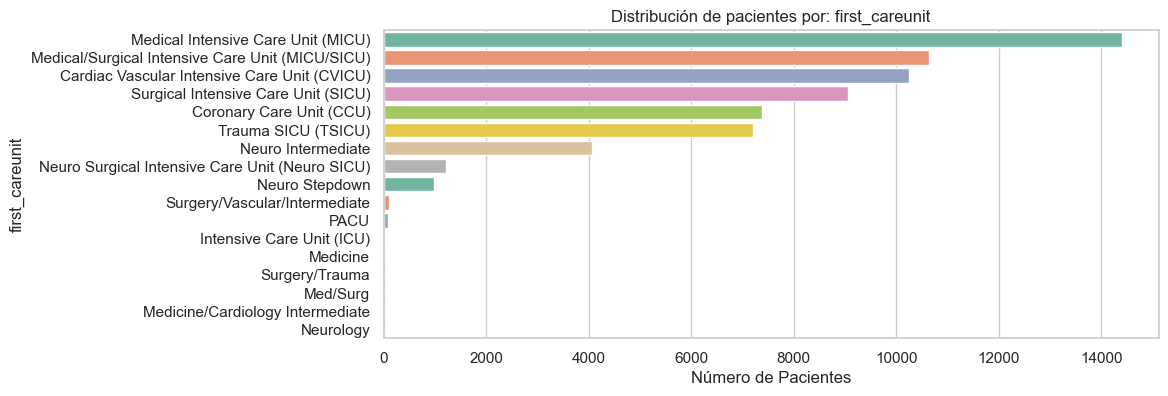

C:\Users\Javi\AppData\Local\Temp\ipykernel_28788\3373531559.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=plot_data, y=col, order=order, palette='Set2')


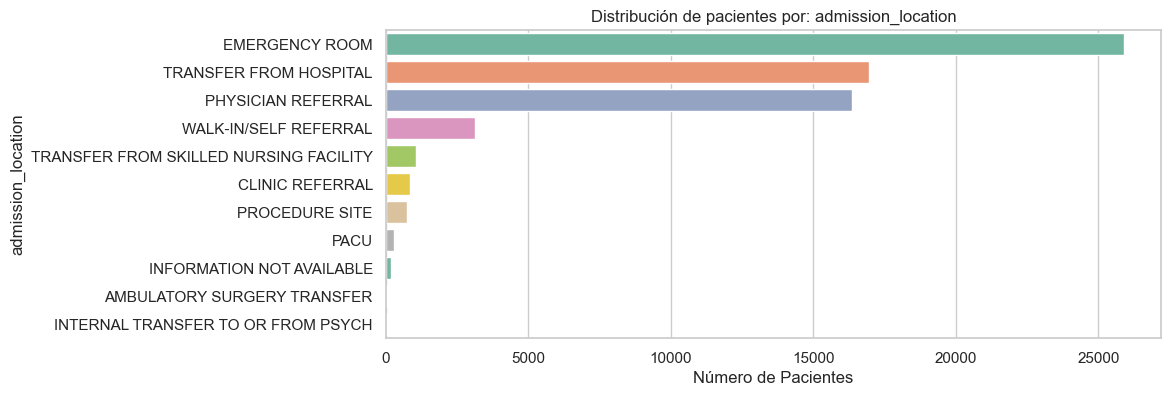

C:\Users\Javi\AppData\Local\Temp\ipykernel_28788\3373531559.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=plot_data, y=col, order=order, palette='Set2')


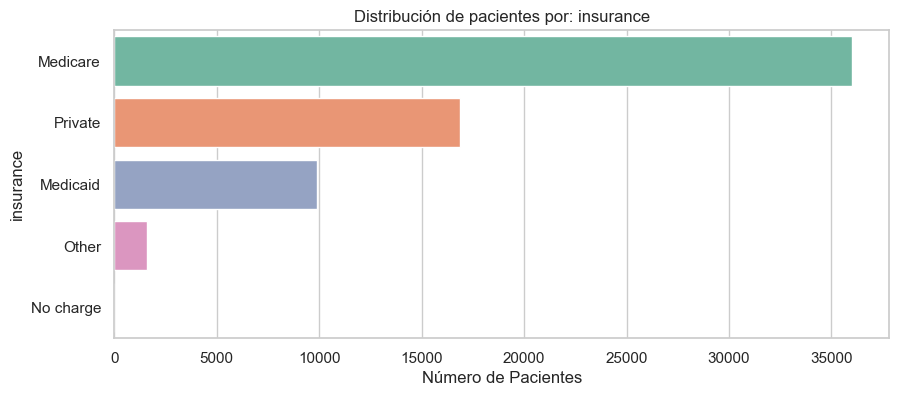

In [23]:
cat_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()
exclude_cats = ['uniquepid', 'patienthealthsystemstayid', 'patientunitstayid']
cat_cols = [c for c in cat_cols if c not in exclude_cats]

for col in cat_cols:
    plt.figure(figsize=(10, 4))
    # Limit labels or rotate if many unique values
    n_unique = df_train[col].nunique()
    if n_unique > 20:
        print(f'\nMostrando top 20 categorías de {col} (total: {n_unique})')
        order = df_train[col].value_counts().head(20).index
        plot_data = df_train[df_train[col].isin(order)]
    else:
        order = df_train[col].value_counts().index
        plot_data = df_train
        
    sns.countplot(data=plot_data, y=col, order=order, palette='Set2')
    plt.title(f'Distribución de pacientes por: {col}')
    plt.xlabel('Número de Pacientes')
    plt.ylabel(col)
    plt.show()

## Distribución de Variables Numéricas (Boxplots)

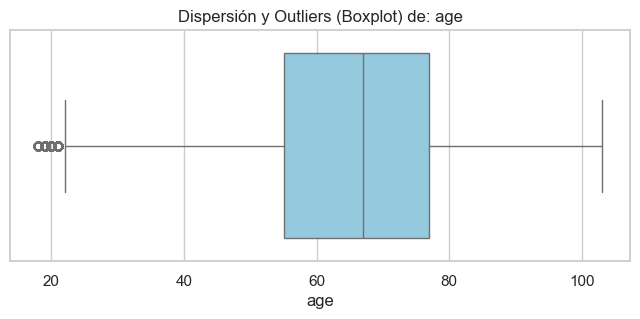

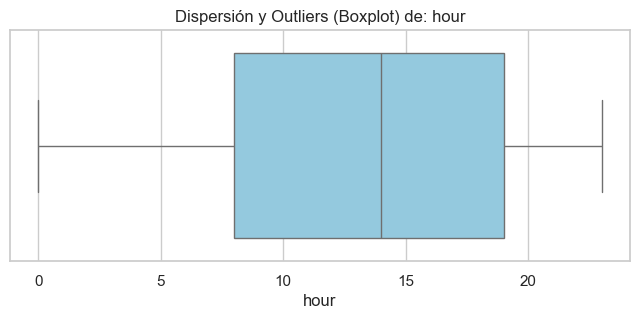

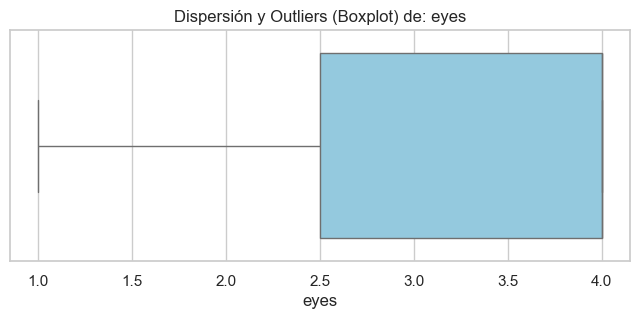

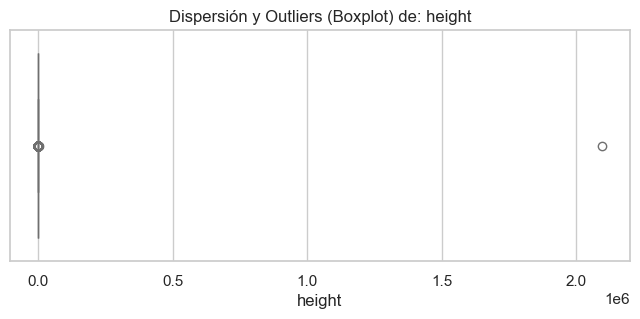

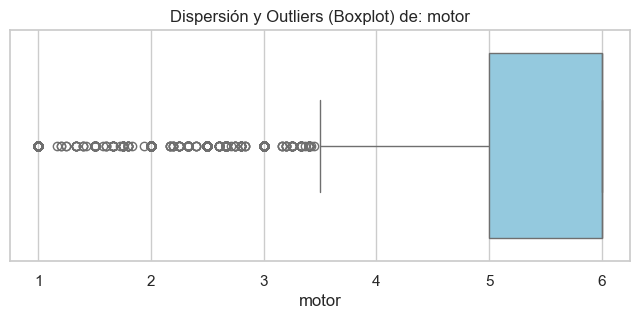

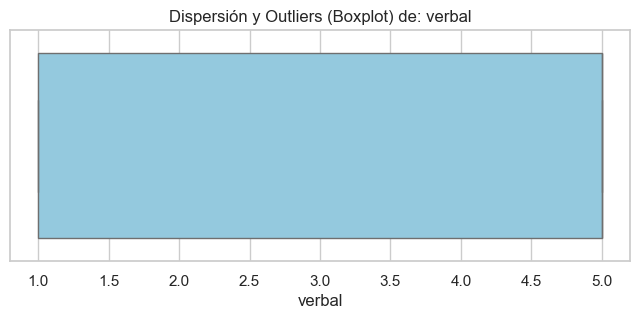

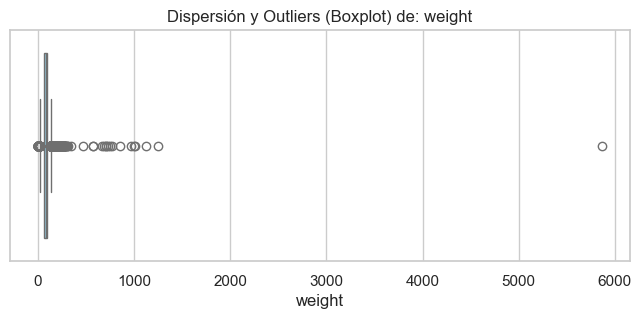

In [24]:
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
exclude_nums = ['uniquepid', 'patienthealthsystemstayid', 'patientunitstayid', 'actualhospitalmortality', 'actualiculos']
num_cols = [c for c in num_cols if c not in exclude_nums]

for col in num_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_train[col], color='skyblue')
    plt.title(f'Dispersión y Outliers (Boxplot) de: {col}')
    plt.xlabel(col)
    plt.show()

## Relación de Variables con la Mortalidad Hospitalaria (`actualhospitalmortality`)

================ Tasas de Mortalidad por Variable Categórica ================


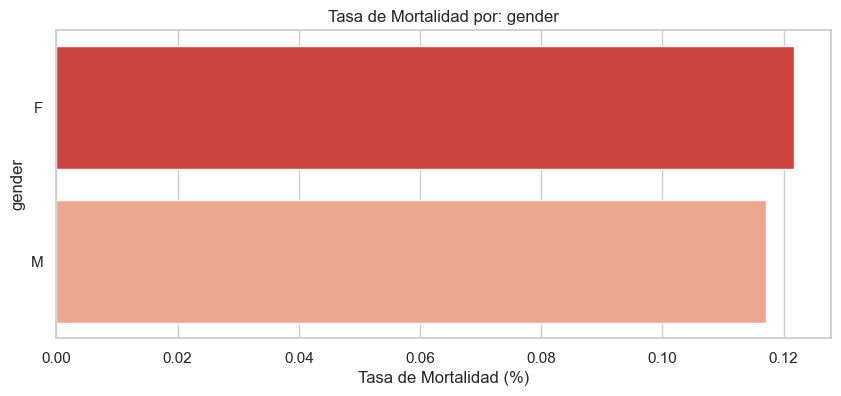

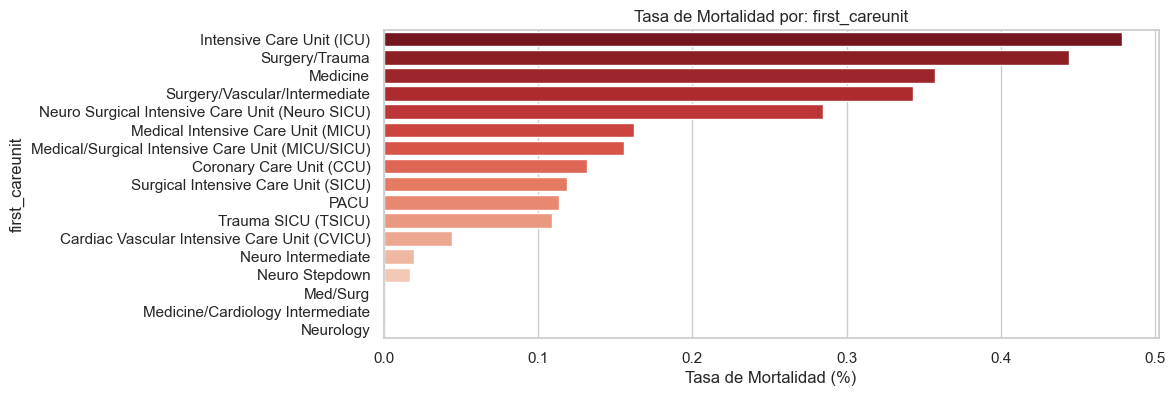

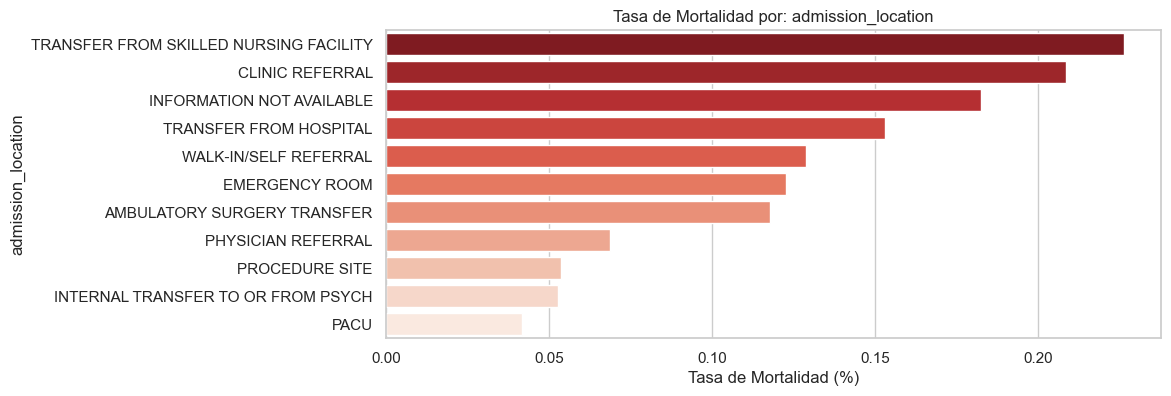

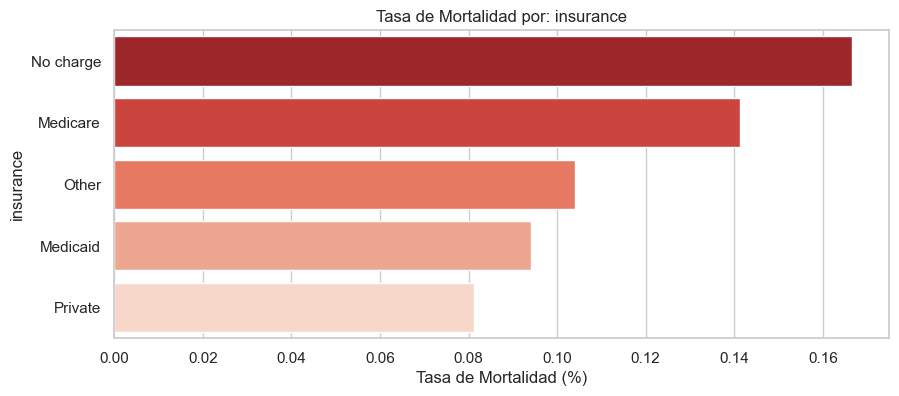

In [25]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

print("================ Tasas de Mortalidad por Variable Categórica ================")
for col in cat_cols:
    n_unique = df_train[col].nunique()
    if n_unique > 20:
        continue
    
    plt.figure(figsize=(10, 4))
    # sns.barplot asume el valor medio, que si es [0,1] coincide exactamente con el % de mortalidad
    order = df_train.groupby(col)['actualhospitalmortality'].mean().sort_values(ascending=False).index
    sns.barplot(data=df_train, y=col, x='actualhospitalmortality', order=order, palette='Reds_r', ci=None)
    plt.title(f'Tasa de Mortalidad por: {col}')
    plt.xlabel('Tasa de Mortalidad (%)')
    plt.ylabel(col)
    plt.show()

================ Distribución Numérica según Mortalidad ================


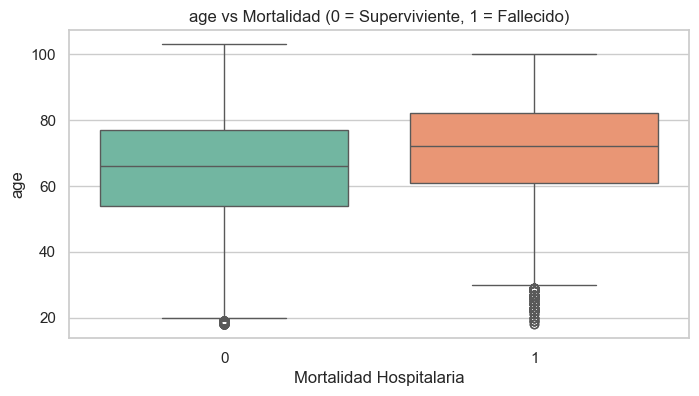

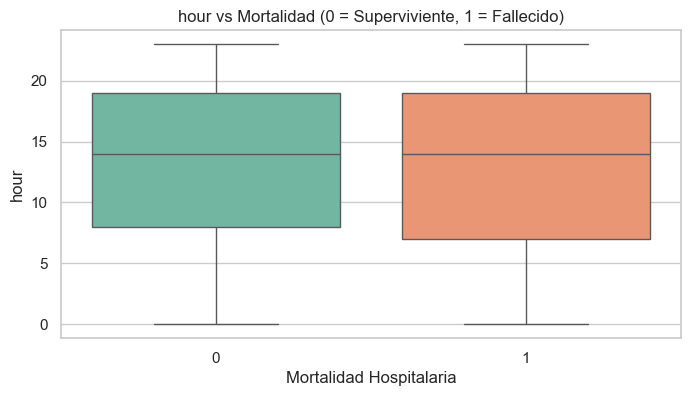

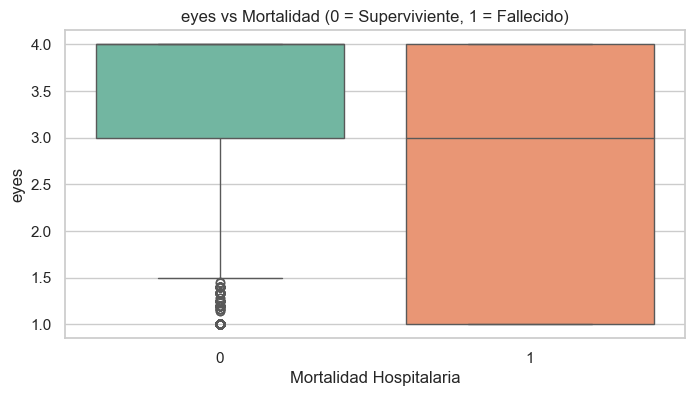

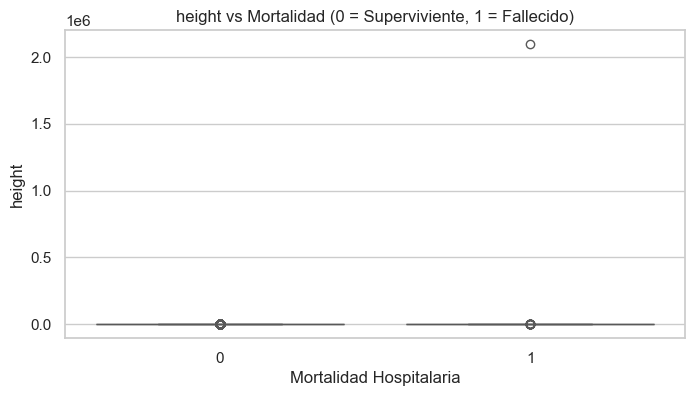

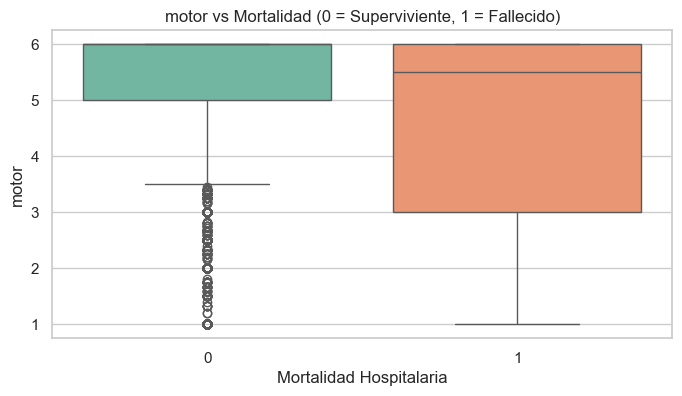

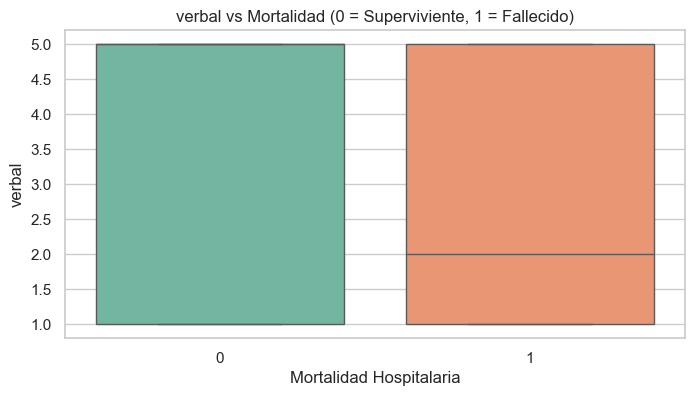

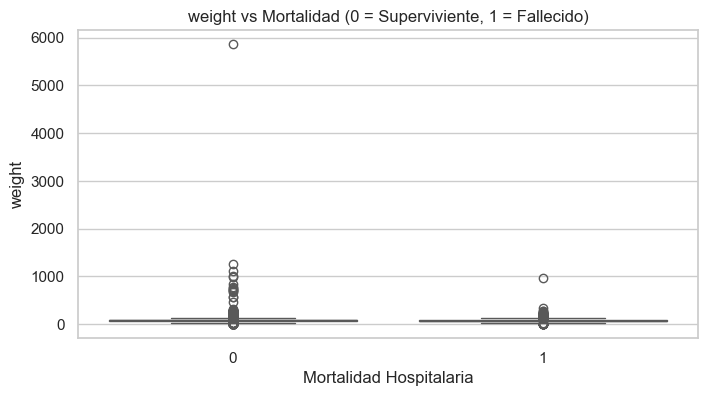

In [26]:
print("================ Distribución Numérica según Mortalidad ================")
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_train, x='actualhospitalmortality', y=col, palette='Set2')
    plt.title(f'{col} vs Mortalidad (0 = Superviviente, 1 = Fallecido)')
    plt.xlabel('Mortalidad Hospitalaria')
    plt.ylabel(col)
    plt.show()

## Relación de Variables con el Tiempo de Estancia (`actualiculos`)

================ Tiempo de Estancia (LOS) por Variable Categórica ================


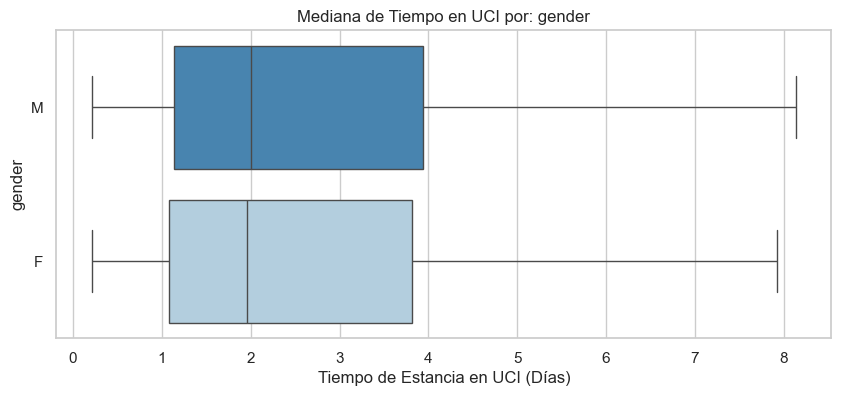

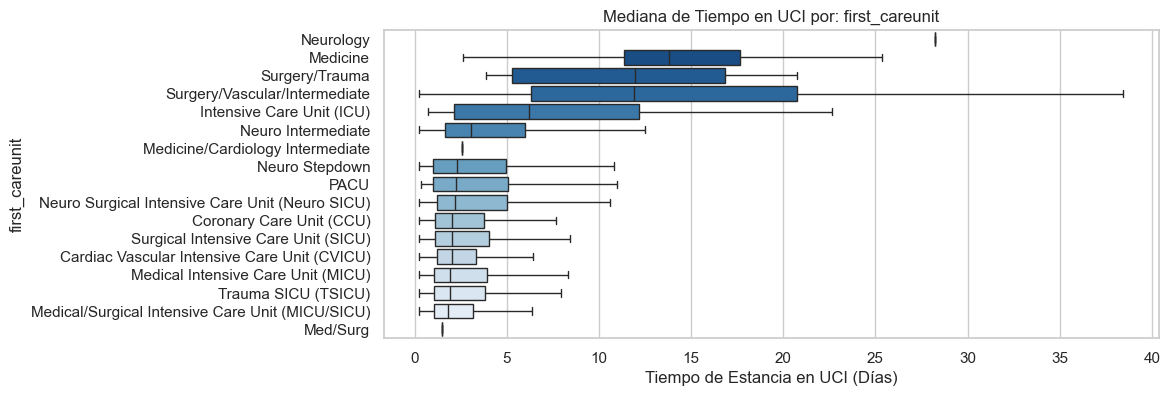

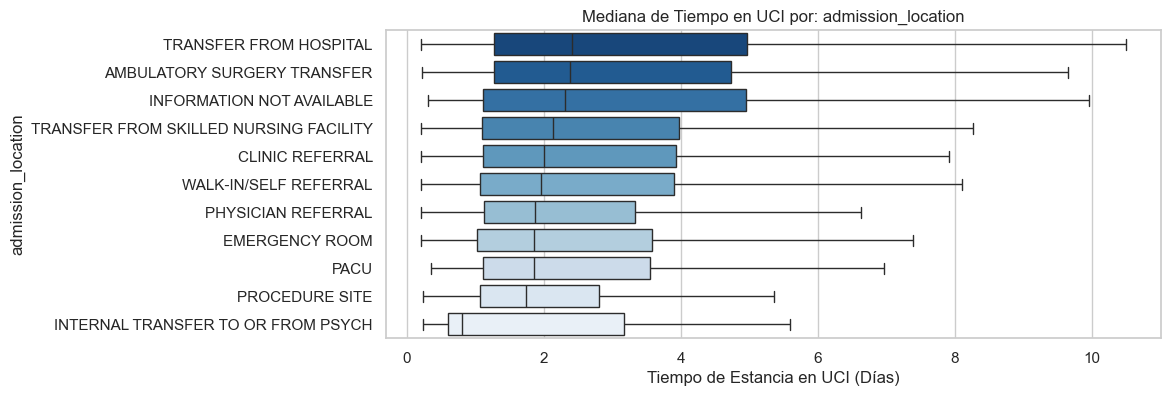

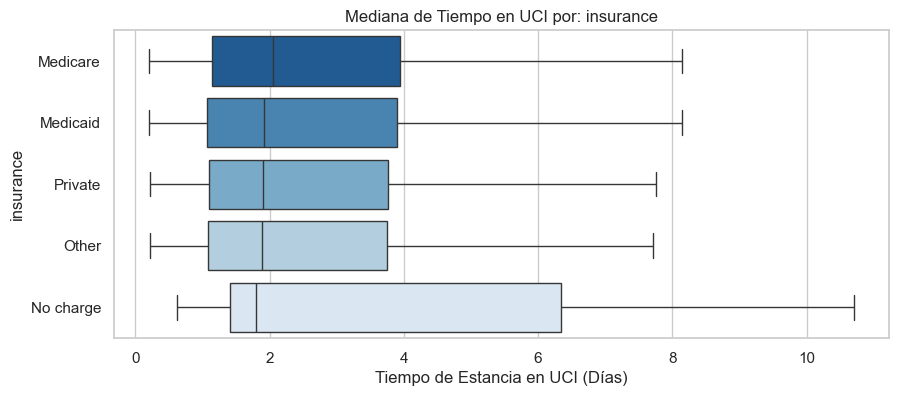

In [27]:
print("================ Tiempo de Estancia (LOS) por Variable Categórica ================")
for col in cat_cols:
    n_unique = df_train[col].nunique()
    if n_unique > 20: 
        continue
    
    plt.figure(figsize=(10, 4))
    order = df_train.groupby(col)['actualiculos'].median().sort_values(ascending=False).index
    # showfliers=False apaga las colas larguísimas de LOS para poder apreciar donde cae la caja
    sns.boxplot(data=df_train, y=col, x='actualiculos', order=order, palette='Blues_r', showfliers=False) 
    plt.title(f'Mediana de Tiempo en UCI por: {col}')
    plt.xlabel('Tiempo de Estancia en UCI (Días)')
    plt.ylabel(col)
    plt.show()

================ Correlación Numérica con Tiempo en UCI ================


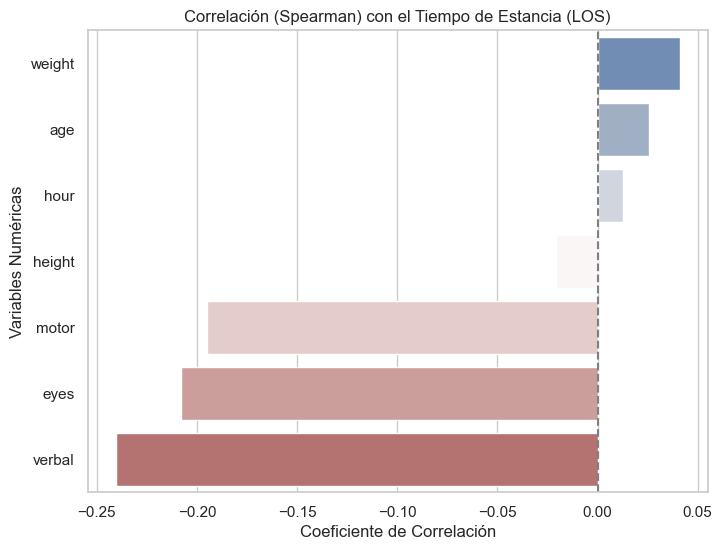


--- Top 3 variables correlacionadas (Scatter plots) ---


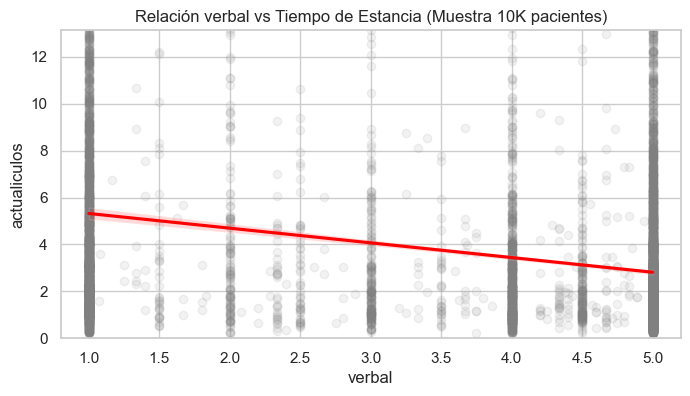

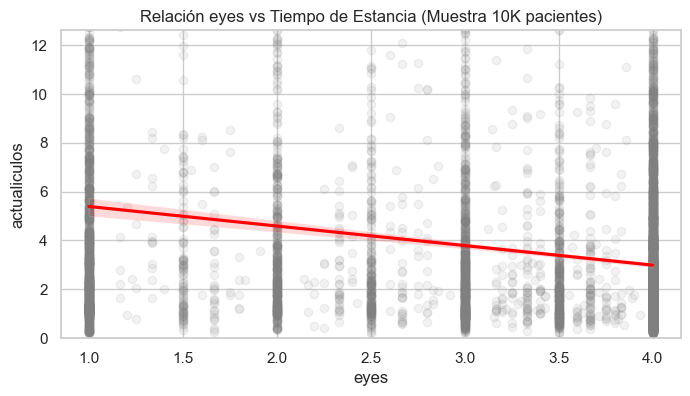

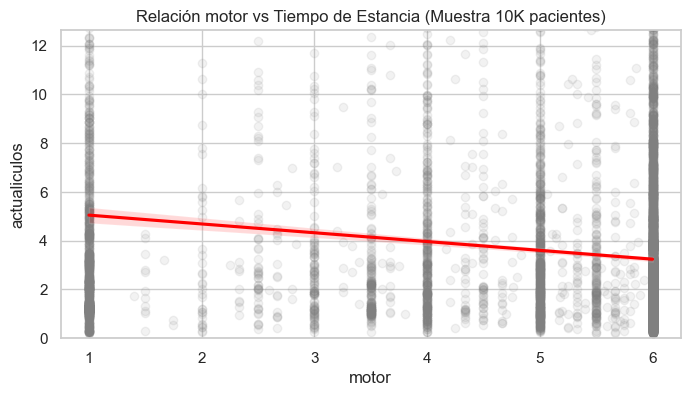

In [28]:
print("================ Correlación Numérica con Tiempo en UCI ================")
# Usamos Spearman ya que las variables biológicas y tiempos no suelen tener relaciones puramente lineales
corr_matrix = df_train[num_cols + ['actualiculos']].corr(method='spearman')
corr_los = corr_matrix[['actualiculos']].sort_values(by='actualiculos', ascending=False)
corr_los = corr_los.drop('actualiculos')

plt.figure(figsize=(8, 6))
sns.barplot(x=corr_los['actualiculos'], y=corr_los.index, palette='vlag')
plt.title('Correlación (Spearman) con el Tiempo de Estancia (LOS)')
plt.xlabel('Coeficiente de Correlación')
plt.ylabel('Variables Numéricas')
plt.axvline(0, color='grey', linestyle='--')
plt.show()

# Scatter plots para el Top 3 absolutos de correlación
top_vars = corr_los['actualiculos'].abs().nlargest(3).index.tolist()
print("\n--- Top 3 variables correlacionadas (Scatter plots) ---")
for col in top_vars:
    plt.figure(figsize=(8, 4))
    sample_df = df_train.dropna(subset=[col, 'actualiculos']).sample(n=min(10000, len(df_train)), random_state=42)
    sns.regplot(data=sample_df, x=col, y='actualiculos', scatter_kws={'alpha':0.1, 'color': 'gray'}, line_kws={'color':'red'})
    plt.title(f'Relación {col} vs Tiempo de Estancia (Muestra 10K pacientes)')
    plt.ylim(0, sample_df['actualiculos'].quantile(0.95)) # Recortar outliers exagerados de LOS
    plt.show()